c:\Users\jigar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model Accuracy: 0.94
Classification Report:
               precision    recall  f1-score   support

    Negative       0.67      0.13      0.22       179
     Neutral       0.53      0.07      0.13       295
    Positive       0.94      1.00      0.97      6452

    accuracy                           0.94      6926
   macro avg       0.71      0.40      0.44      6926
weighted avg       0.92      0.94      0.91      6926



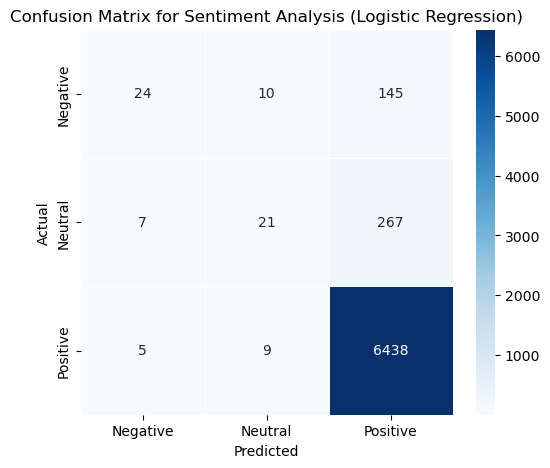

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset
def load_data(file_path):
    return pd.read_csv(file_path)

# Preprocess data
def preprocess_data(df):
    df = df.drop_duplicates(subset='product_review', keep='first')
    df = df.dropna(subset=['product_review'])
    df['product_review'] = df['product_review'].astype(str)
    return df

# Load dataset
input_file = "product_reviews_with_sentiment.csv"
df = load_data(input_file)
df = preprocess_data(df)

# Map product_rating to sentiment label
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment_Category'] = df['product_rating'].apply(rating_to_sentiment)

# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['product_review']).toarray()

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Sentiment_Category'])

# Prepare training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_val, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

# Plot confusion matrix as heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Sentiment Analysis (Logistic Regression)")
plt.show()
